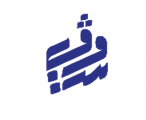
#  **Notebook d'Analyse de Qualité des Donnée(Data Quality)**
# **Sujet : E-Commerce Sougui Shop**

# Data Quality – Projet BI E-commerce

Objectif :
 1. Importer des données depuis différents formats (PDF, Excel, CSV, XML, etc.)
 2. Analyser la qualité des données selon plusieurs dimensions
 3. Générer des rapports et visualisations
 4. Proposer des corrections et améliorations

<span style="color:#B39DDB ">

## **Installation et configuration**
</span>

In [75]:
!pip install pandas numpy openpyxl xlrd odfpy pyxlsb pdfplumber lxml beautifulsoup4 matplotlib seaborn plotly missingno -q

<span style="color:#B39DDB ">

##  **Importation des bibliothèques**
</span>

In [76]:
import pandas as pd
import numpy as np
import os
import json
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

#sns.set(style='whitegrid')

In [77]:
# visualisations
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
#import missingno as msno

<span style="color:#B39DDB ">

##  **Chargement des fichiers**
</span>

In [78]:
def load_file(file_path, **kwargs):
    ext = os.path.splitext(file_path)[1].lower()

    if ext == '.xlsx':
        return pd.read_excel(file_path, engine='openpyxl', **kwargs)
    elif ext == '.xlsm':
        return pd.read_excel(file_path, engine='openpyxl', **kwargs)
    elif ext == '.xls':
        return pd.read_excel(file_path, engine='xlrd', **kwargs)
    elif ext == '.ods':
        return pd.read_excel(file_path, engine='odf', **kwargs)
    else:
        raise ValueError(f"Format Excel non supporté: {ext}")


<span style="color:#B39DDB ">

## **Produits_Sougui_SiteWeb**
</span>

In [79]:
Df_Produits_Sougui_SiteWeb=load_file(r"C:\Users\eree\Desktop\wetransfer_artisanat-zip_2026-01-21_0929\artisanat\artisanat\web_site_data\Produits_Sougui-Siteweb.xlsx")


<span style="color:#B39DDB ">

## **Vue d’ensemble des données**
</span>

In [80]:
Df_Produits_Sougui_SiteWeb.head()

,ID,Type,UGS,Nom,Catégories,Publié,Visibilité dans le catalogue,Mis en avant ?,Tarif régulier,Tarif promo,En stock ?,Stock,Description courte,État de la TVA,Prix effectif
0,11808,simple,NBK-001-OSL,Jeu Nes Bekri Kalou ناس بكري قالوا,Jeux,1,visible,0,30,NaN,1,NaN,"<p><span style=""font-family: Roboto, Arial, sa...",taxable,30.0
1,11873,simple,SS-MT-01,Jeu De Mimes - ميم بالتونسي - Jeu D'ambiance,Jeux,1,visible,0,58,NaN,1,NaN,Plongez dans l'ambiance festive avec notre jeu...,taxable,58.0
2,11880,simple,SS-JB-001,لعبة الباندي - Jeu D’ambiance,Jeux,1,visible,0,46,NaN,1,NaN,"لعبة الباندي بالتونسي المساند <span style=""fo...",taxable,46.0
3,11887,simple,LB-001-SB,Lunch-box Bento,Shop,1,visible,0,70,"49,9",0,NaN,<p>Boîte à bento empilable beige écologique | ...,taxable,49.9
4,11900,simple,SS-TT-001,طلّع بالتونسي - TALA3 BITOUNSI,Jeux,1,visible,0,48,NaN,1,NaN,"Découvrez le jeu ""Talla3 B'Tounsi"", une expér...",taxable,48.0


In [81]:
print(f"nombre colonnes : {Df_Produits_Sougui_SiteWeb.shape[1]}\nnombre des lignes {Df_Produits_Sougui_SiteWeb.shape[0]}")

nombre colonnes : 15
nombre des lignes 237


In [82]:
print(f"clonnes : {Df_Produits_Sougui_SiteWeb.columns.to_list()}")

clonnes : ['ID', 'Type', 'UGS', 'Nom', 'Catégories', 'Publié', 'Visibilité dans le catalogue', 'Mis en avant ?', 'Tarif régulier', 'Tarif promo', 'En stock ?', 'Stock', 'Description courte', 'État de la TVA', 'Prix effectif']


In [83]:
print(Df_Produits_Sougui_SiteWeb.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            237 non-null    int64  
 1   Type                          237 non-null    object 
 2   UGS                           218 non-null    object 
 3   Nom                           237 non-null    object 
 4   Catégories                    126 non-null    object 
 5   Publié                        237 non-null    int64  
 6   Visibilité dans le catalogue  237 non-null    object 
 7   Mis en avant ?                237 non-null    int64  
 8   Tarif régulier                206 non-null    object 
 9   Tarif promo                   64 non-null     object 
 10  En stock ?                    237 non-null    object 
 11  Stock                         46 non-null     float64
 12  Description courte            127 non-null    object 
 13  État 

In [84]:
Df_Produits_Sougui_SiteWeb.describe().round(2)

,ID,Publié,Mis en avant ?,Stock,Prix effectif
count,237.00,237.0,237.00,46.00,205.00
mean,13102.20,1.0,0.00,1.87,86.55
std,607.06,0.0,0.06,6.31,83.61
min,11808.00,1.0,0.00,0.00,15.00
25%,12586.00,1.0,0.00,0.00,25.00
50%,13091.00,1.0,0.00,0.00,56.00
75%,13751.00,1.0,0.00,1.00,119.00
max,14037.00,1.0,1.00,40.00,399.00



<span style="color:#B39DDB ">

## **Unicité Metier**
</span>

In [85]:
Df_Produits_Sougui_SiteWeb["UGS"].duplicated().sum()

np.int64(18)

<span style="color:pink">
on a 18 doublons d'UGS
<span/>


<span style="color:#B39DDB ">

## **Identifier le type de doublon**
</span>

In [86]:
Df_Produits_Sougui_SiteWeb[Df_Produits_Sougui_SiteWeb["UGS"].duplicated(keep=False)].sort_values("UGS")


,ID,Type,UGS,Nom,Catégories,Publié,Visibilité dans le catalogue,Mis en avant ?,Tarif régulier,Tarif promo,En stock ?,Stock,Description courte,État de la TVA,Prix effectif
42,12425,simple,NaN,Sculpture Tête de Cheval en Raku - Édition Art...,Shop > Déco > Sculptures,1,visible,0,280,240,1,NaN,<h3><br></h3><p>Magnifique sculpture artisanal...,taxable,240.0
43,12426,simple,NaN,Sculpture Hibou en Raku - Édition Artisanale,Shop > Déco > Sculptures,1,visible,0,240,220,1,NaN,<h3><br></h3><p>Sculpture artisanale en raku d...,taxable,220.0
44,12427,simple,NaN,Vase Buste en Raku - Édition Artisanale,Shop > Déco > Sculptures,1,visible,0,360,280,1,NaN,"<h3><br></h3><p>Vase en forme de buste, fabriq...",taxable,280.0
45,12429,simple,NaN,Sculpture Poisson en Raku - Édition Artisanale,Shop > Déco > Sculptures,1,visible,0,260,230,1,NaN,<p>Sculpture artisanale en raku représentant u...,taxable,230.0
46,12431,simple,NaN,Sculpture Cheval en Raku - Édition Équestre Ar...,Shop > Déco > Sculptures,1,visible,0,280,240,1,NaN,"<h3><br></h3><p>Sculpture en raku d'un cheval,...",taxable,240.0
47,12453,simple,NaN,Veilleuse Coquille en Fibres Végétales et Fer,Shop > Déco > Luminaires,1,visible,0,150,NaN,1,1.0,<h3><br></h3><p>Élégante veilleuse en forme de...,taxable,150.0
48,12455,simple,NaN,Veilleuse Citrouille en Fibres Végétales et Fer,Shop > Déco > Luminaires,1,visible,0,150,NaN,1,NaN,<p><h3></h3></p><p>Veilleuse en forme de citro...,taxable,150.0
49,12457,simple,NaN,Veilleuse Diamant en Fibres Végétales et Fer,Shop > Déco > Luminaires,1,visible,0,150,NaN,0,0.0,"<h3><br></h3><p>Veilleuse en forme de diamant,...",taxable,150.0
50,12459,simple,NaN,Applique Murale Diamant en Fibres Végétales et...,Shop > Déco > Luminaires,1,visible,0,130,NaN,0,0.0,<h3><br></h3><p>Applique murale en fibres végé...,taxable,130.0
51,12461,simple,NaN,Applique Murale Marabout en Fibres Végétales e...,Shop > Déco > Luminaires,1,visible,0,130,NaN,0,0.0,<h3><br></h3><p>Applique murale artisanale en ...,taxable,130.0


<span style="color:pink">
ce ne sont pas des doublons,

 **problème de complétude de clé métier** : on doit avoir une clé metier valide pour tous les produits or ce n est pas le cas on a des clés métier incomplètes (non renseignées)
<span/>


<span style="color:#B39DDB ">

##  **valeurs manquantes (NaN)**
</span>

In [87]:
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    mis_val_table = pd.DataFrame({
        'Missing Values': mis_val,
        '% of Total': mis_val_percent
    })
    mis_val_table = mis_val_table[mis_val_table['Missing Values'] > 0].sort_values('% of Total', ascending=False)
    return mis_val_table

In [88]:
print("Les Valeurs Manquantes de la table des produits du siteweb de sougui:\n", missing_values_table(Df_Produits_Sougui_SiteWeb))

Les Valeurs Manquantes de la table des produits du siteweb de sougui:
                     Missing Values  % of Total
Stock                          191   80.590717
Tarif promo                    173   72.995781
Catégories                     111   46.835443
Description courte             110   46.413502
Prix effectif                   32   13.502110
Tarif régulier                  31   13.080169
UGS                             19    8.016878


<span style="color:pink">


**Stock (80%)** la majorité des produits  sont sans gestion de stock

**Tarif promo (73%)**  Normal : la majorité des produits n’est pas en promo

**Catégories (47%)** Un produit sur deux sans catégorie cela rendrait la navigation du site mauvaise le client ne peut pas trouver facilement les produits recherchés 

**Description courte (46%)**  mauvais marketing

**Prix effectif – 13.50% et Tarif régulier – 13.080%**: quasi complètes (risque faible) mais certaines lignes ne peuvent pas être utilisées dans les analyses de chiffre d’affaires.

Les colonnes ID, Nom, Type, Publié, TVA, Visibilité, En stock : sont parfaitement completes
<span/>

<span style="color:#C9A227">

les ugs de quelques produits sont  **manquants**  
ils ne figurent dans aucun fichier et ne se trouvent pas dans le site donc on doit generer nous meme des ugs pour ces articles
</span>


<span style="color:#B39DDB ">

## **Graphiques des valeurs Manquantes**
</span>

Fonction pour afficher les pourcentages des valeurs null

In [89]:
def afficherPoucentageNull(Df):    
# Trouver les colonnes avec valeurs nulles
    colonnes_nulls = {}
    for col in Df.columns:
        nb_nulls = Df[col].isnull().sum()
        if nb_nulls > 0:
            pourcentage = (nb_nulls / len(Df)) * 100
            colonnes_nulls[col] = pourcentage

    if colonnes_nulls:
        # Trier par pourcentage
        colonnes = list(colonnes_nulls.keys())
        pourcentages = list(colonnes_nulls.values())

    # Graphique
    plt.figure(figsize=(16, 6))
    bars = plt.bar(colonnes, pourcentages, color='pink',edgecolor='black')
    plt.xlabel('Colonnes')
    plt.ylabel('Pourcentage de valeurs nulles')

    plt.title('Valeurs nulles par colonne')
    plt.ylabel('% de valeurs nulles')
    plt.xticks(
        ticks=range(len(colonnes)),
        labels=colonnes,
        rotation=45,
        ha='right'
    )

    # ➕ Affichage des valeurs exactes sur les barres
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.2f}%',   # 2 décimales
            ha='center',
            va='bottom'
        )

    plt.tight_layout()
    plt.show()

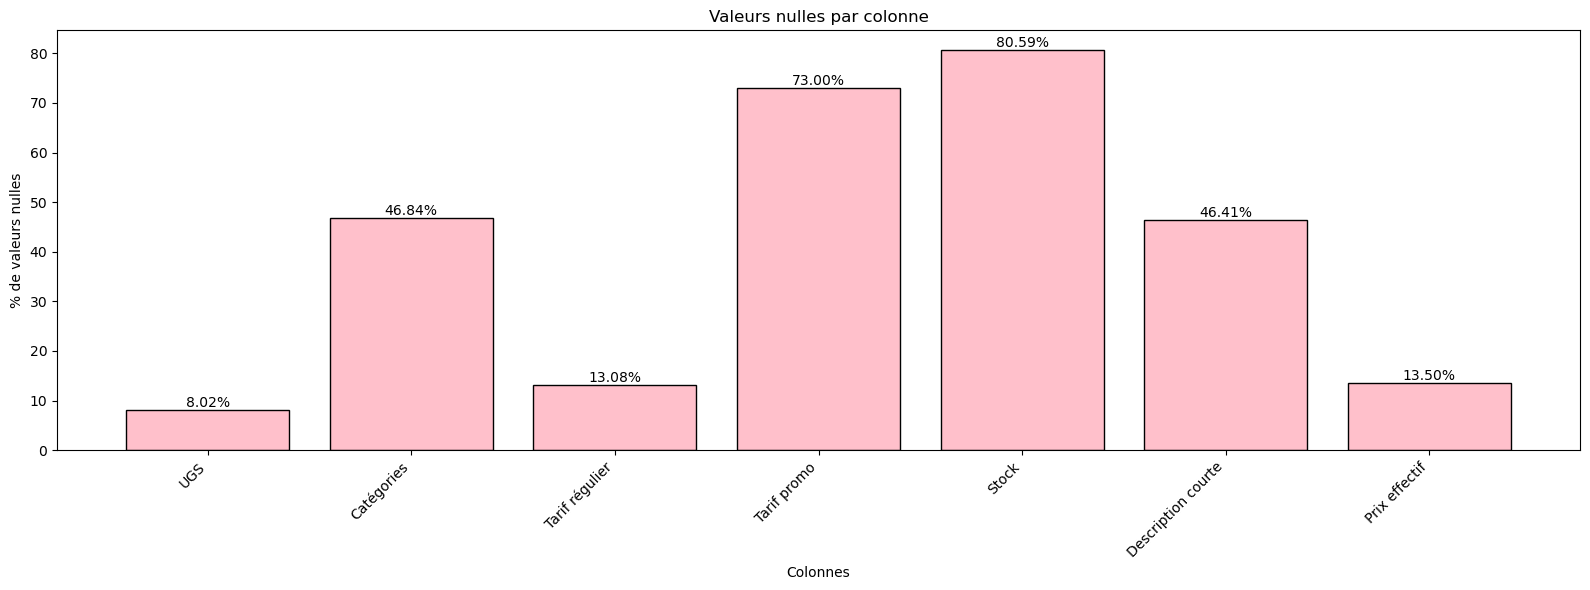

In [90]:
afficherPoucentageNull(Df_Produits_Sougui_SiteWeb)

<span style="color:#B39DDB ">

## **Analyse de complétude**
</span>


pour les valeurs manquantes pour pouvoir calculer le data quality

In [91]:
completude = (1 - Df_Produits_Sougui_SiteWeb.isnull().mean()) * 100
completude.sort_values()

Stock                            19.409283
Tarif promo                      27.004219
Catégories                       53.164557
Description courte               53.586498
Prix effectif                    86.497890
Tarif régulier                   86.919831
UGS                              91.983122
Type                            100.000000
Mis en avant ?                  100.000000
Visibilité dans le catalogue    100.000000
Publié                          100.000000
Nom                             100.000000
ID                              100.000000
En stock ?                      100.000000
État de la TVA                  100.000000
dtype: float64

<span style="color:#B39DDB ">

## **Score global Data Quality**
</span>

In [92]:
score = {
    "completude": 1 - Df_Produits_Sougui_SiteWeb.isnull().mean().mean(),
    "unicite": 1 - Df_Produits_Sougui_SiteWeb["UGS"].duplicated().mean(),
    "validite_prix": Df_Produits_Sougui_SiteWeb["Prix effectif"].notna().mean()
}

pd.DataFrame(score, index=["DQ Score"]).T


,DQ Score
completude,0.812377
unicite,0.924051
validite_prix,0.864979


<span style="color:pink">

**Complétude – 81%**
En moyenne, 19% des données sont manquantes
a cause de colonnes  Stock (19%),Catégories (53%) Description (53%) qui sont manquantes

**Unicité – 92%**
Très bon score, Peu de risques de doublons techniques donc les identifiants sont stables

**Validité des prix – 86**%
 14% de valeurs prix manquantes ou invalides
donc il y a des Risques sur :CA ,marges et les analyses comparatives
certaines lignes ne peuvent pas être utilisées pour le calcul du chiffre d’affaires.
</span>

<span style="color:#B39DDB ">

## **Pertinence des colonnes**
</span>

## **La colonne : Publié**

pour la colonne publié le min et le max sont egaux et sont egals a 1 donc elle présente une absence totale de variabilité (valeur constante)
Elle est donc non informative d’un point de vue analytique et ne permet aucune exploitation métier

## **La colonne : Visibilité dans le catalogue**

In [93]:
Df_Produits_Sougui_SiteWeb['Visibilité dans le catalogue'].nunique()


1

La colonne visibilité dans le catalogue ne varie pas donc sa valeur est toujours "visible"


In [94]:
duplicates = Df_Produits_Sougui_SiteWeb[Df_Produits_Sougui_SiteWeb.duplicated()]
print("Nombre de doublons :", duplicates.shape[0])

Nombre de doublons : 0


<span style="color:pink">

**aucune ligne n a exactement les memes valeurs pour toutes les colonnes** 


**On n a aucun produit qui est dupliqué completement**


</span>


<span style="color:#B39DDB ">

## **Valeurs des colonnes categorie et type**
</span>

## **La colonne : Type**

In [95]:
Df_Produits_Sougui_SiteWeb['Type'].value_counts()

Type
variation    110
simple        95
variable      29
grouped        3
Name: count, dtype: int64

In [96]:
Df_Produits_Sougui_SiteWeb['Type'].value_counts(normalize=True) * 100


Type
variation    46.413502
simple       40.084388
variable     12.236287
grouped       1.265823
Name: proportion, dtype: float64

## **La colonne : Categorie**

In [97]:
Df_Produits_Sougui_SiteWeb['Catégories'].value_counts()


Catégories
Shop > Arts de la table > Céramiques                                                            25
Shop > Arts de la table > Cuivres                                                               14
Shop > Arts de la table, Shop > Arts de la table > Céramiques                                   10
Shop > Arts de la table > Service de Table                                                       8
Shop > Déco > Sculptures                                                                         7
Jeux                                                                                             7
Shop > Arts de la table > Céramiques, Shop > Gifts > Esprit Romance                              6
Shop > Déco > Luminaires                                                                         6
Shop > Déco > Vases                                                                              4
Shop > Arts de la table > Verres                                                                 3

In [98]:
Df_Produits_Sougui_SiteWeb['Catégories'].value_counts(normalize=True) * 100


Catégories
Shop > Arts de la table > Céramiques                                                            19.841270
Shop > Arts de la table > Cuivres                                                               11.111111
Shop > Arts de la table, Shop > Arts de la table > Céramiques                                    7.936508
Shop > Arts de la table > Service de Table                                                       6.349206
Shop > Déco > Sculptures                                                                         5.555556
Jeux                                                                                             5.555556
Shop > Arts de la table > Céramiques, Shop > Gifts > Esprit Romance                              4.761905
Shop > Déco > Luminaires                                                                         4.761905
Shop > Déco > Vases                                                                              3.174603
Shop > Arts de la table > Verres   

<span style="color:pink">
il faut regrouper certaines categories ensemble car elle representent la meme chose comme par exemple Shop > Arts de la table > Céramiques et Shop > Arts de la table, Shop > Arts de la table > Céramiques
</span>


<span style="color:#B39DDB ">

## **Graphiques des valeurs aberrantes**
</span>

<span style="color:pink">
on doit convertir les tarifs et les prix qui sont de type object pour pouvoir visualiser les valeurs abberantes a l aide des boxplots
</span>

In [99]:
for col in ['Tarif régulier', 'Tarif promo']:
    Df_Produits_Sougui_SiteWeb[col + '_num'] = (
        Df_Produits_Sougui_SiteWeb[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
        .replace('nan', None)
        .astype(float)
    )


print("CHECK:", Df_Produits_Sougui_SiteWeb[['Tarif régulier','Tarif promo']].dtypes)

CHECK: Tarif régulier    object
Tarif promo       object
dtype: object



<span style="color:#B39DDB ">

## **Boxplot des tarifs reguliers**
</span>

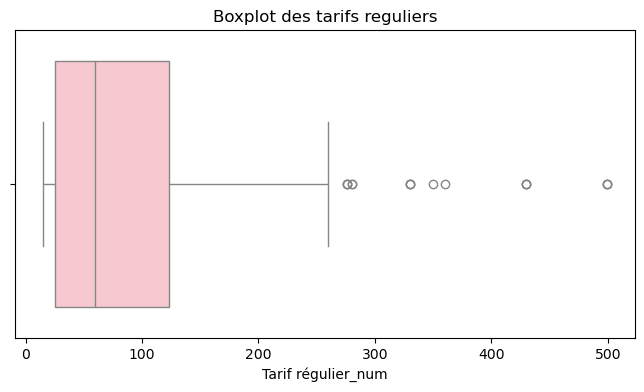

In [100]:
plt.figure(figsize=(8,4))
sns.boxplot(x=Df_Produits_Sougui_SiteWeb['Tarif régulier_num'], color='pink')
plt.title('Boxplot des tarifs reguliers')
plt.show()

<span style="color:pink">
La médiane (le trait au milieu de la boîte) est située autour de 60–70:50 % des tarifs réguliers sont inférieurs à cette valeur et 50 % supérieurs


La boîte (Q1–Q3) s’étend approximativement de 30 à 110:La moitié des tarifs réguliers se situe donc dans cet intervalle

on observe plusieurs points isolés à droite 

 : Ce sont des tarifs exceptionnellement élevés, rares par rapport au reste des données.

La distribution est asymétrique à droite (skewed right) :

Beaucoup de tarifs relativement bas ou moyens

Quelques tarifs très élevés qui tirent la distribution vers la droite
</span>



<span style="color:#B39DDB ">

## **Boxplot des tarifs promo**
</span>

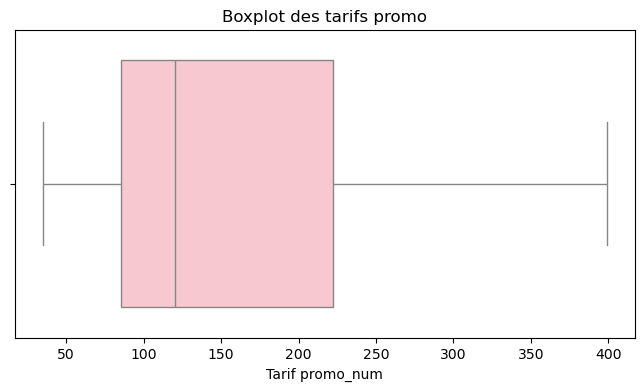

In [101]:
plt.figure(figsize=(8,4))
sns.boxplot(x=Df_Produits_Sougui_SiteWeb['Tarif promo_num'], color='pink')
plt.title('Boxplot des tarifs promo')
plt.show()

<span style="color:pink">

La médiane est autour de 120–130.
 La moitié des tarifs promotionnels est donc en dessous de cette valeur.



La boîte (Q1–Q3) s’étend approximativement de 80 à 220.
 50 % des tarifs promo se trouvent dans cet intervalle, ce qui montre une forte variabilité.


La moustache gauche descend vers 40, correspondant aux promos les plus basses.

La moustache droite monte jusqu’à environ 400, indiquant des tarifs promo très élevés.


Contrairement aux tarifs réguliers, on ne voit pas de points isolés :
il n’y a pas d’outliers clairement identifiés ici.

 Forme de la distribution

La distribution est asymétrique à droite, avec une longue queue vers les valeurs élevées.

Les tarifs promo restent souvent plus élevés que les tarifs réguliers médians, ce qui peut paraître surprenant.
</span>


<span style="color:#B39DDB ">

## **Boxplot des prix effectifs**
</span>

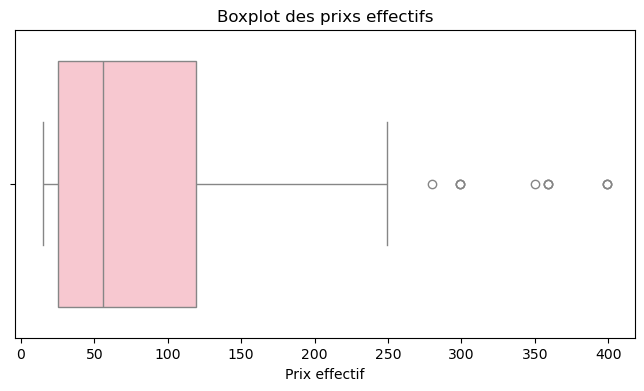

In [102]:
plt.figure(figsize=(8,4))
sns.boxplot(x=Df_Produits_Sougui_SiteWeb['Prix effectif'], color='pink')
plt.title('Boxplot des prixs effectifs')
plt.show()

<span style="color:pink">
Position centrale
La médiane se situe autour de 50–60.
Cela signifie que 50 % des prix effectifs sont inférieurs ou sup à cette valeur.

Dispersion (boîte)

La boîte (Q1–Q3) est approximativement entre 25 et 110.
 La moitié des prix effectifs se concentre donc dans cette plage, avec une dispersion modérée à élevée.

Moustaches

La moustache gauche descend vers 15–20, correspondant aux prix les plus bas non aberrants.

La moustache droite monte jusqu’à environ 250, ce qui représente la limite supérieure normale.

Valeurs aberrantes

On observe plusieurs outliers à droite (environ 280, 300, 350, 400).
Ce sont des prix effectifs exceptionnellement élevés, peu fréquents.

Forme de la distribution

La distribution est clairement asymétrique à droite :

Beaucoup de prix bas ou moyens

Quelques prix très élevés qui étirent la distribution
</span>


<span style="color:#B39DDB ">

## **Pourcentage d anomalies**
</span>

In [103]:
def count_outliers_iqr(df, colonne):
    serie = df[colonne].dropna()

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    borne_inf = q1 - 1.5 * iqr
    borne_sup = q3 + 1.5 * iqr

    outliers = serie[(serie < borne_inf) | (serie > borne_sup)]

    return len(outliers)


In [104]:
def percent_outliers_iqr(df, colonne):
    serie = df[colonne].dropna()
    return (count_outliers_iqr(df, colonne) / len(serie)) * 100


<span style="color:#B39DDB ">


## **Anomalies pour les tarifs reguliers**
</span>

In [106]:
a =count_outliers_iqr(Df_Produits_Sougui_SiteWeb, "Tarif régulier_num")
b =percent_outliers_iqr(Df_Produits_Sougui_SiteWeb, "Tarif régulier_num")
print(f"Le nombre d'outliers est {a}, donc leur pourcentage est {b:.2f}%")


Le nombre d'outliers est 16, donc leur pourcentage est 7.77%


<span style="color:pink">

**7.77%** des tarifs reguliers sont des **valeurs aberrantes**
</span>

<span style="color:#B39DDB ">

## **Anomalies pour les tarifs promo**
</span>

In [107]:
a =count_outliers_iqr(Df_Produits_Sougui_SiteWeb, "Tarif promo_num")
b =percent_outliers_iqr(Df_Produits_Sougui_SiteWeb, "Tarif promo_num")
print(f"Le nombre d'outliers est {a}, donc leur pourcentage est {b:.2f}%")

Le nombre d'outliers est 0, donc leur pourcentage est 0.00%


<span style="color:pink">

**aucun** outlier dans les tarifs **promo**
</span>

<span style="color:#B39DDB ">

## **Anomalies pour les prix effectifs**
</span>

In [109]:
a =count_outliers_iqr(Df_Produits_Sougui_SiteWeb, "Prix effectif")
b =percent_outliers_iqr(Df_Produits_Sougui_SiteWeb, "Prix effectif")
print(f"Le nombre d'outliers est {a}, donc leur pourcentage est {b:.2f}%")

Le nombre d'outliers est 11, donc leur pourcentage est 5.37%


<span style="color:pink">

**5.37%** des prix effectifs sont des outliers
</span>

<span style="color:#B39DDB ">

## **Verification des promos**
</span>

In [110]:
incoherent = Df_Produits_Sougui_SiteWeb[
    (Df_Produits_Sougui_SiteWeb["Tarif promo_num"].notna()) &
    (Df_Produits_Sougui_SiteWeb["Prix effectif"] != Df_Produits_Sougui_SiteWeb["Tarif promo_num"])
]

len(incoherent)

0

<span style="color:pink">
On récupère les lignes incohérentes :

produits avec une promo définie, mais le prix effectif ne correspond pas au tarif promo
len(incoherent)=0  AUCUNE incohérence trouvée
</span>

<span style="color:#B39DDB ">

## **Verification du stock**
</span>

In [111]:
erreurs_stock = Df_Produits_Sougui_SiteWeb[
    (Df_Produits_Sougui_SiteWeb["En stock ?"] == "yes") &
    (Df_Produits_Sougui_SiteWeb["Stock"].fillna(0) <= 0)
]
len(erreurs_stock)

0

<span style="color:pink">
il n’existe aucun produit qui dit :“ en stock” alors que son stock est nul, négatif ou manquant
</span>

In [112]:
Df_Produits_Sougui_SiteWeb["En stock ?"].value_counts()

En stock ?
1            121
0            113
backorder      3
Name: count, dtype: int64

<span style="color:pink">
donc 0.51% des produits sont en stock
</span>

In [113]:
Df_Produits_Sougui_SiteWeb["Stock"].isna().sum()

np.int64(191)

In [114]:
(Df_Produits_Sougui_SiteWeb["Stock"] <= 0).sum()

np.int64(32)

<span style="color:pink">
pour 191 produits :
le stock n’est pas renseigné ou il était non numérique et a été converti en NaN

32 produits ont un stock ≤ 0, donc :stock = 0 (rupture) ou stock négatif (erreur ou backorder)

Incohérence métier claire
</span>


<span style="color:#B39DDB ">

## **Analyse des corrélations**
</span>

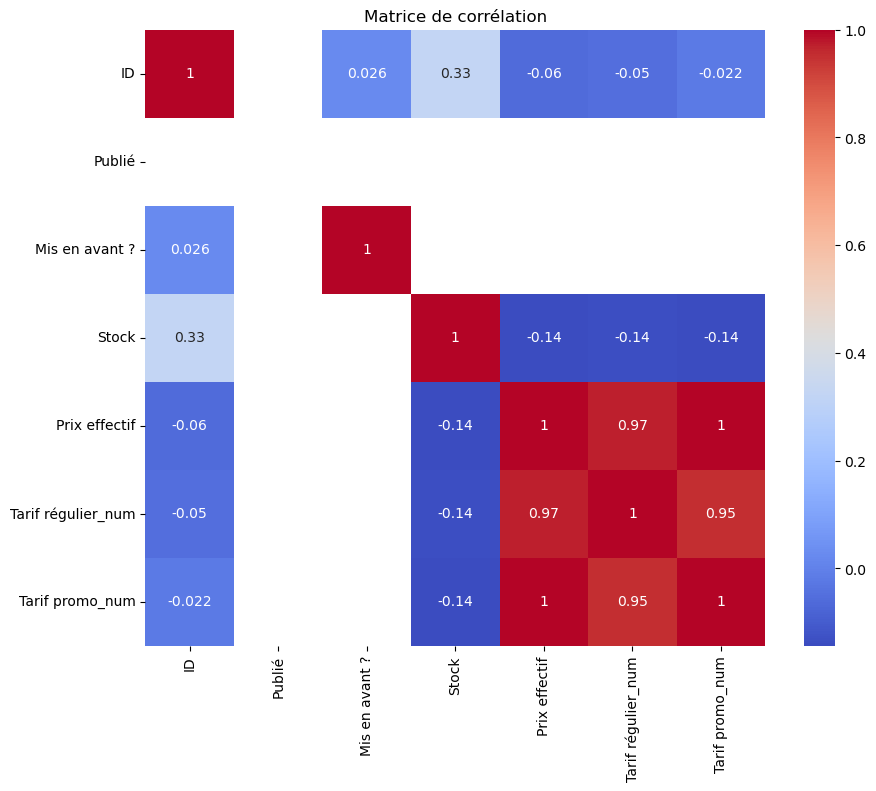

In [115]:
numeriques = Df_Produits_Sougui_SiteWeb.select_dtypes(include=['float', 'int', 'Int64']).columns
corr = Df_Produits_Sougui_SiteWeb[numeriques].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matrice de corrélation')
plt.show()



<span style="color:red ">



## **Corrélations fortes  :Variables de prix**

</span>

Prix effectif ↔ Tarif promo_num : corrélation = 1

Prix effectif ↔ Tarif régulier_num : corrélation = 0.97

Tarif régulier_num ↔ Tarif promo_num : corrélation = 0.95

**Ces variables sont presque identiques d’un point de vue statistique.**
**C’est normal : le prix effectif est directement calculé à partir du tarif régulier et/ou promo.**


Cela crée de la multicolinéarité → il faudra en garder une seule dans un modèle.


<span style="color:blue ">

## **Corrélations faibles (quasi nulles)**

</span>

## **ID**

ID n’est corrélé à rien (logique)
 C’est une variable technique, à exclure des analyses.

<span style="color:blue ">

## **Corrélations faibles mais intéressantes**
</span>
Stock ↔ Prix

Stock ↔ Prix effectif = -0.14

Stock ↔ Tarif régulier = -0.14

Stock ↔ Tarif promo = -0.14
Quand le stock augmente, le prix a tendance à baisser légèrement, mais l’effet est faible.


## **correlation nulle : Mis en avant ?**

Corrélation ≈ 0 avec les prix et le stock
 Être mis en avant n’influence pas directement le prix ou le stock




<span style="color:#B39DDB ">

## **Distribution des données**
</span>

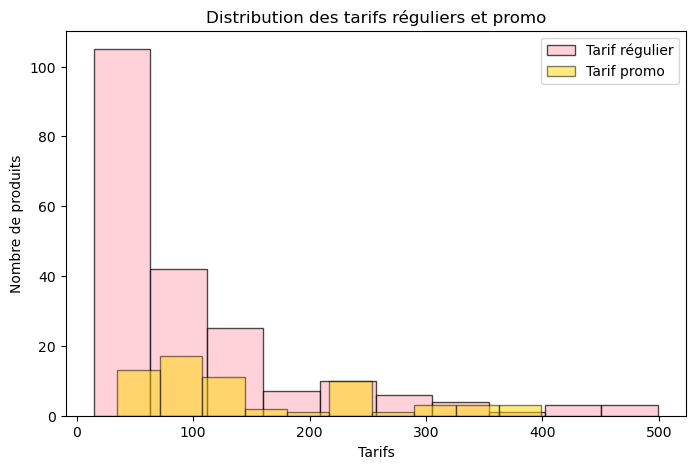

In [117]:
plt.figure(figsize=(8,5))
plt.hist(Df_Produits_Sougui_SiteWeb['Tarif régulier_num'].dropna(), bins=10, color='pink', edgecolor='black', alpha=0.7)
plt.hist(Df_Produits_Sougui_SiteWeb['Tarif promo_num'].dropna(), bins=10, color='gold', edgecolor='black', alpha=0.5)
plt.xlabel('Tarifs')
plt.ylabel('Nombre de produits')
plt.title('Distribution des tarifs réguliers et promo')
plt.legend(['Tarif régulier', 'Tarif promo'])
plt.show()


<span style="color:pink">

La majorité des produits ont un prix entre ~20 et 120

Forte concentration de produits à bas prix

Longue queue jusqu’à 500 → quelques produits très chers (outliers)

Distribution asymétrique à droite (classique en e-commerce)
**Le catalogue est majoritairement composé de produits abordables, avec quelques produits premium.**
</span>


<span style="color:gold">

Beaucoup moins de valeurs que le tarif régulier
(normal → tous les produits ne sont pas en promo)

Promotions surtout entre 40 et 150

Quelques promos sur des produits chers (jusqu’à 400)

Distribution plus étalée 
**Les promotions sont sélectives et concernent surtout des produits milieu de gamme.**

</span>





<span style="color:#B39DDB ">

## **Problèmes identifiés**
</span>


<span style="color:#B39DDB ">

## **Recommandations**
</span>